<div style="text-align:center; padding:20px 0">
<img src="https://raw.githubusercontent.com/dataprojectlabs/DataProjectLab-projects/refs/heads/main/media/logo_dataprojectlab.png" width="220"/>
</div>

# AfriCare Support Analytics
## Notebook 1 — Contexte, Brief Métier & Données
### ✅ VERSION CORRIGÉE

---

> **Comment lire ce notebook :**
> Chaque bloc de code est précédé d'une cellule markdown qui explique **pourquoi** on fait ce qu'on fait — pas seulement **comment**.
> Les cellules grises `# POINT PÉDAGOGIQUE` contiennent les enseignements à retenir.
> Lis toujours la cellule d'explication avant d'exécuter le code.

---

| Info | Détail |
|---|---|
| **Niveau** | Avancé |
| **Outils** | Python, SQL, ML, Power BI |
| **Durée estimée** | 3h à 4h |
| **Compétences travaillées** | Business understanding · Audit qualité · Premiers KPIs · Visualisation décisionnelle |

---

# 1. La mission

Tu es Data Analyst chez **AfriCare Services**, un opérateur multi-pays (telecom, fintech, e-commerce) présent dans 8 pays d'Afrique et d'Europe.

Le Directeur du Support Client, **M. Eric KOUAME**, t'a confié une mission stratégique pour piloter et améliorer la performance du service client.

# 2. Le brief métier

> *"On gère plus de 5 000 tickets par mois et franchement, on perd le fil. Certains clients attendent 3 jours pour une réponse qui aurait dû venir en 2 heures. Nos agents ne savent pas quoi traiter en priorité. Les SLA explosent sur certaines catégories et personne ne comprend pourquoi.*
>
> *Ce dont j'ai besoin : comprendre où sont nos vrais problèmes. Ensuite, un outil qui prédit si un ticket est à risque — à risque de dépasser son SLA, de partir en backlog, ou de provoquer une escalade. Comme ça, mes superviseurs peuvent intervenir avant que ça parte en vrille.*
>
> *Et en bonus, un dashboard complet pour piloter mes 12 agents au quotidien."*

— M. Eric KOUAME, Directeur du Support Client, AfriCare Services

---

### 🎓 Ce que ce brief nous dit en tant qu'analyste

Ce brief est riche. Décortiquons les attentes réelles de M. Kouame :

**Attente 1 — "Comprendre où sont nos vrais problèmes"**
→ C'est une demande d'**analyse descriptive** : SQL, EDA, visualisations. Le Notebook 1 et 2.

**Attente 2 — "Un outil qui prédit si un ticket est à risque"**
→ C'est une demande de **modèle prédictif** : classification ML binaire. Le Notebook 3 (ou 4 selon organisation).
→ La variable cible est implicite dans sa phrase : SLA breach | backlog | escalade = ticket à risque.

**Attente 3 — "Un dashboard pour piloter mes agents"**
→ C'est une demande de **dashboard décisionnel** : Power BI, mesures DAX. Le Notebook 5.

**Ce que M. Kouame ne dit pas mais qui est implicite :**
Le vrai enjeu n'est pas le SLA en lui-même — c'est la **perte client**. Un client qui attend 3 jours pour une réponse risque de churner. Le SLA est le proxy mesurable de cette satisfaction. Notre analyse doit garder cet objectif final en tête.

---

# 3. Les axes d'analyse

Les analyses s'articulent autour de **6 axes** :

1. **Volume et tendances** — combien de tickets, quelle évolution, quelle saisonnalité ?
2. **Performance SLA** — où les délais explosent-ils et pourquoi ?
3. **Performance agents** — qui performe, qui est surchargé, qui génère des escalades ?
4. **Backlog et tickets bloqués** — quel est le poids des tickets en attente ?
5. **Satisfaction client (CSAT)** — quel est le lien entre délai et satisfaction ?
6. **Prédiction de risque (ML)** — peut-on détecter un ticket à risque dès sa création ?

---

# 4. Dictionnaire des données

> 🎓 **Avant de toucher au code, lisez toujours le dictionnaire en entier.**
> C'est l'étape la plus sous-estimée par les analystes juniors. Connaître la sémantique
> de chaque colonne évite des erreurs d'interprétation coûteuses plus tard.

---

## `tickets.csv` — Table principale (15 287 lignes)

| Colonne | Type | Description |
|---|---|---|
| `ticket_id` | str | Identifiant unique — format TKT000001 |
| `created_at` | datetime | Horodatage de création (YYYY-MM-DD HH:MM:SS) |
| `category_id` | str | FK vers `categories.csv` |
| `agent_id` | str | FK vers `agents.csv` |
| `pays` | str | Pays du client |
| `canal` | str | Canal d'entrée : Email / Chat / Téléphone / App mobile / Web form |
| `priorite` | int | Priorité assignée (1=urgent à 5=basse) |
| `statut` | str | Résolu / En cours / Backlog / Escaladé / Fermé |
| `sla_heures` | float | SLA applicable en heures (varie selon la catégorie) |
| `first_response_heures` | float | Délai avant première réponse (heures) |
| `resolution_heures` | float | Durée totale de résolution (heures) |
| `sla_breach` | int | **⭐ Variable cible principale** : 1 si SLA dépassé, 0 sinon |
| `nb_contacts` | int | Nombre de contacts pour résoudre le ticket |
| `reopened` | int | 1 si le ticket a été rouvert |
| `csat` | float | Note de satisfaction 1 à 5 (NULL si pas de retour client) |
| `in_backlog` | int | 1 si le ticket est en backlog |
| `ratio_sla` | float | `resolution_heures / sla_heures` — ratio > 1 = breach |

> 🎓 **Point clé :** `sla_breach` et `ratio_sla` sont liés logiquement.
> Si `ratio_sla > 1` alors `sla_breach` **doit** valoir 1. Vérifier cette cohérence
> est l'une des premières vérifications à faire dans l'audit.

---

## `agents.csv` — Équipe support (12 lignes)

| Colonne | Type | Description |
|---|---|---|
| `agent_id` | str | Identifiant unique |
| `nom` | str | Nom de l'agent |
| `tier` | str | Tier 1 (basique) / Tier 2 (avancé) / Tier 3 (expert) |
| `bureau` | str | Localisation géographique |
| `csat_moyen` | float | Note CSAT historique moyenne de l'agent |
| `taux_resolution_pct` | float | % de tickets résolus sans escalade |
| `tickets_actifs` | int | Nombre de tickets en cours actuellement |

---

## `categories.csv` — Types de demandes (10 lignes)

| Colonne | Type | Description |
|---|---|---|
| `category_id` | str | Identifiant (CAT001 à CAT010) |
| `nom` | str | Libellé de la catégorie |
| `domaine` | str | Billing / Technical / Delivery / Legal / Security |
| `priorite_defaut` | int | Priorité par défaut de 1 (urgente) à 5 (basse) |
| `sla_strict` | bool | True si le SLA est contractuellement engagé |
| `sla_heures` | float | Délai SLA maximal en heures |
| `taux_resolution_historique` | float | Taux de résolution observé historiquement |

---

## `interactions.csv` — Historique des actions (~15 000 lignes)

| Colonne | Type | Description |
|---|---|---|
| `interaction_id` | str | Identifiant unique |
| `ticket_id` | str | FK vers `tickets.csv` |
| `timestamp` | datetime | Horodatage de l'action |
| `agent_id` | str | Agent qui a effectué l'action |
| `action_type` | str | Note interne / Email client / Escalade / Résolution / Transfert |
| `visible_client` | bool | True si l'action est visible par le client |

---

## `sla_alerts.csv` — Alertes SLA (~2 000 lignes)

| Colonne | Type | Description |
|---|---|---|
| `ticket_id` | str | FK vers `tickets.csv` (tickets en breach uniquement) |
| `alert_timestamp` | datetime | Moment où l'alerte a été déclenchée |
| `depassement_heures` | float | Nombre d'heures de dépassement |
| `statut_notification` | str | Notifié / Non notifié / En attente |
| `manager_alerte` | bool | True si le manager a été notifié |

---

# Tâche 0 — Réflexion stratégique

> 🎓 **Pourquoi cette tâche existe :**
> Un analyste qui commence à coder sans avoir réfléchi au problème métier va dans le mur.
> Cette tâche force la réflexion **avant** d'ouvrir un fichier.
> Les réponses ici ne sont pas des vérités absolues — elles sont des hypothèses de départ
> qu'on testera et affinera avec les données.

### Question 1 — Qu'est-ce qu'un ticket "à risque" ? 3 critères

**Critère 1 — Délai de première réponse élevé**
Si `first_response_heures` approche ou dépasse le SLA, le ticket risque de breacher.
Un ticket sans première réponse rapide crée une **spirale de frustration** : le client relance,
`nb_contacts` augmente, le ticket devient complexe à résoudre.

**Critère 2 — Priorité haute + catégorie SLA strict**
Un ticket `priorite = 1` dans une catégorie `sla_strict = True` sans réponse rapide est critique.
La combinaison priorité urgente + engagement contractuel SLA = risque legal ET client.

**Critère 3 — Agent assigné surchargé**
Si l'agent a un `tickets_actifs` élevé ou un `taux_resolution_pct` faible, le ticket risque de stagner.
Ce critère est souvent invisible dans les systèmes CRM — c'est pourtant l'un des facteurs
de breach les plus évitables.

---

### Question 2 — La variable cible pour le modèle ML

```python
# Variable cible binaire : ticket à risque = 1
# On combine 3 signaux métier en une seule variable composite
tickets['ticket_at_risk'] = (
    (tickets['sla_breach'] == 1) |   # SLA déjà dépassé
    (tickets['in_backlog'] == 1) |   # Ticket bloqué en backlog
    (tickets['statut'] == 'Escaladé') # Ticket qui a nécessité une escalade
).astype(int)
```

> 🎓 **Pourquoi cette combinaison ?**
> Ces trois signaux capturent des formes différentes de "ticket problématique" :
> - `sla_breach` : problème de **délai** (le ticket est trop lent)
> - `in_backlog` : problème de **blocage** (le ticket est coincé dans la file)
> - `statut = 'Escaladé'` : problème de **complexité** (l'agent n'a pas pu le gérer seul)
>
> Un ticket peut satisfaire un seul critère, deux, ou les trois.
> L'union (`|`) capture tous ces cas. Cette définition composite correspond
> exactement à ce que M. Kouame veut prévenir.

---

### Question 3 — L'erreur la plus coûteuse : faux négatif

**Ne pas alerter (faux négatif) est plus coûteux qu'alerter à tort (faux positif).**

Un faux négatif = un ticket critique non détecté. Conséquences possibles :
- Escalade non anticipée → superviseur débordé → effet domino sur les autres tickets
- Violation contractuelle SLA → pénalité financière
- Perte client → coût d'acquisition pour le remplacer

Un faux positif = alerter un superviseur pour un ticket qui se serait bien résolu seul.
Coût : quelques minutes de vérification. Gérable.

> 🎓 **Implication sur le modèle ML :**
> Ce raisonnement justifie d'optimiser le **Recall** (sensibilité) plutôt que la Precision.
> On préfère alerter trop souvent plutôt que rater une alerte critique.
> Dans le Notebook 4 (ML), on choisira le seuil de décision en conséquence.

---

### Question 4 — Interprétation du ratio_sla

```
ratio_sla = resolution_heures / sla_heures
```

- `ratio_sla = 0.3` → ticket résolu en 30% du temps alloué → **excellente performance**
- `ratio_sla = 1.0` → ticket résolu exactement dans le délai SLA → **juste dans les clous**
- `ratio_sla = 1.5` → ticket a pris 1.5× le temps SLA → **breach de 50%**
- `ratio_sla = 3.0` → ticket a pris 3× le temps SLA → **breach critique**

> 🎓 **Attention au piège :**
> Un `ratio_sla` de 0 (résolution instantanée) est suspect — vérifier si ce n'est pas
> une erreur de saisie ou une fermeture automatique sans résolution réelle.
> On le vérifiera dans l'audit de cohérence.

---

### Question 5 — Variables à fort impact sur le CSAT

En ordre décroissant d'impact attendu :

1. **`resolution_heures`** — plus le délai est long, plus le CSAT baisse. Relation quasi-linéaire.
2. **`nb_contacts`** — plus de contacts = friction élevée. Un client qui doit rappeler plusieurs fois est frustré.
3. **`reopened`** — ticket rouvert = client insatisfait de la première résolution. Signal fort.
4. **`first_response_heures`** — la première réponse crée la **première impression**. Elle influence toute la suite.
5. **`tier` de l'agent** — les agents Tier 3 résolvent mieux les cas complexes, ce qui améliore le CSAT sur ces tickets.

> 🎓 **Ces hypothèses seront testées dans le Notebook 2 (EDA).**
> On les note ici pour avoir une référence. Si les données contredisent ces hypothèses,
> c'est un insight encore plus intéressant à documenter.

---

# Tâche 1 — Chargement des données

> 🎓 **Ordre des opérations :**
> 1. Importer les librairies et configurer l'environnement
> 2. Charger les 5 fichiers CSV
> 3. Vérifier immédiatement les dimensions
>
> Ne jamais passer à l'analyse sans avoir vérifié que le chargement s'est bien passé.
> Une erreur silencieuse dans `read_csv` (mauvais séparateur, encodage incorrect)
> peut fausser toute l'analyse qui suit.

### Configuration de l'environnement

Avant tout, on configure l'affichage et les styles globaux.
Ces deux lignes de configuration sont souvent négligées — elles ont pourtant un impact direct
sur la lisibilité de tous les outputs du notebook.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings



warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)

# Style global — fond sombre cohérent avec le dashboard Power BI
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('✅ Environnement prêt')

✅ Environnement prêt


### Chargement des 5 fichiers

> 🎓 **`parse_dates` est obligatoire** sur toutes les colonnes de type horodatage.
>
> Sans `parse_dates=['created_at']`, pandas charge la colonne comme une chaîne de
> caractères (`object`). Conséquences :
> - `tickets['created_at'].dt.month` → `AttributeError`
> - `sort_values('created_at')` → tri alphabétique (faux ordre chronologique)
> - Calculs de durée (`resolution_heures`) impossibles
>
> **Règle : parse_dates dès le `read_csv`, toujours.**

In [15]:
BASE_URL = "https://raw.githubusercontent.com/dataprojectlabs/DataProjectLab-projects/main/projets/customer_support_analytics/data/"


agents     = pd.read_csv(BASE_URL + "agents.csv")
categories = pd.read_csv(BASE_URL + "categories.csv")
tickets    = pd.read_csv(BASE_URL + "tickets.csv", parse_dates=['created_at'])
interactions = pd.read_csv(BASE_URL + "interactions.csv", parse_dates=['timestamp'])
sla_alerts = pd.read_csv(BASE_URL + "sla_alerts.csv", parse_dates=['alert_timestamp'])

# Vérification immédiate des dimensions
print(f"{'Table':<15} {'Lignes':>8} {'Colonnes':>10}")
print("-" * 36)
for name, df in [('tickets', tickets), ('agents', agents), ('categories', categories),
                  ('interactions', interactions), ('sla_alerts', sla_alerts)]:
    print(f"{name:<15} {len(df):>8,} {len(df.columns):>10}")

Table             Lignes   Colonnes
------------------------------------
tickets           15,287         19
agents                12          7
categories            10          7
interactions      15,779          6
sla_alerts         2,000          5


---

# Audit des données

> 🎓 **Pourquoi un audit avant l'analyse ?**
>
> Deux raisons fondamentales :
>
> **Raison 1 — Fiabilité des résultats.**
> Si `sla_breach` contient des valeurs incorrectes, notre taux de breach sera faux.
> On pourrait recommander des actions basées sur des chiffres erronés — c'est la pire
> erreur qu'un analyste puisse faire.
>
> **Raison 2 — Anticipation des problèmes ML.**
> Le Notebook 4 va entraîner un modèle de classification. Les modèles ML sont
> sensibles aux données mal typées, aux nulls non traités, et aux incohérences logiques.
> Nettoyer maintenant évite des erreurs incompréhensibles plus tard.
>
> L'audit se déroule en 4 étapes : types → nulls → doublons → cohérence.

## Étape 1 — Types de données

> 🎓 **Ce qu'on vérifie :**
> - Les colonnes de dates sont-elles bien en `datetime64` ?
> - Les booléens (`sla_breach`, `in_backlog`) sont-ils en `int64` ou `bool`, pas en `object` ?
> - `ratio_sla` est-il bien numérique ?
> - `sla_strict` dans `categories` peut arriver en string `"True"/"False"` — conversion nécessaire.

In [16]:
# Affichage structuré des types pour chaque table
for name, df in [('tickets', tickets), ('agents', agents),
                 ('categories', categories), ('interactions', interactions),
                 ('sla_alerts', sla_alerts)]:
    print(f"\n{'='*50}")
    print(f"  {name.upper()}  —  {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
    print(f"{'='*50}")
    print(df.dtypes.to_string())


  TICKETS  —  15,287 lignes × 19 colonnes
ticket_id                        object
created_at               datetime64[ns]
category_id                      object
agent_id                         object
pays                             object
canal                            object
priorite                          int64
statut                           object
sla_heures                        int64
first_response_heures           float64
resolution_heures               float64
sla_breach                        int64
nb_contacts                       int64
reopened                          int64
csat                            float64
in_backlog                        int64
mois                              int64
jour_semaine                      int64
ratio_sla                       float64

  AGENTS  —  12 lignes × 7 colonnes
agent_id                object
nom                     object
tier                    object
bureau                  object
csat_moyen             float64
taux_

### Corrections de types

> 🎓 **La conversion de `sla_strict` est un cas fréquent en pratique.**
>
> Quand un fichier CSV contient des booléens, Python/pandas les lit parfois comme
> des chaînes de caractères `"True"` et `"False"` (avec guillemets) plutôt que
> comme des booléens `True` et `False`.
>
> `.map({'True': True, 'False': False, True: True, False: False})` gère les deux cas :
> la version string ET la version déjà booléenne.
> C'est une bonne pratique défensive — le code fonctionne même si le CSV change de format.

In [17]:
# Vérification des types critiques
print("Types des colonnes clés dans tickets :")
print(f"  created_at          : {tickets['created_at'].dtype}")
print(f"  sla_breach          : {tickets['sla_breach'].dtype}")
print(f"  priorite            : {tickets['priorite'].dtype}")
print(f"  ratio_sla           : {tickets['ratio_sla'].dtype}")
print(f"  in_backlog          : {tickets['in_backlog'].dtype}")

print("\nType sla_strict dans categories (avant correction) :")
print(f"  sla_strict : {categories['sla_strict'].dtype}")
print(f"  Valeurs uniques : {categories['sla_strict'].unique()}")

# Conversion sla_strict en booléen si arrivé en string
if categories['sla_strict'].dtype == object:
    categories['sla_strict'] = categories['sla_strict'].map(
        {'True': True, 'False': False, True: True, False: False}
    )

print(f"\nType sla_strict après correction : {categories['sla_strict'].dtype} ✅")

Types des colonnes clés dans tickets :
  created_at          : datetime64[ns]
  sla_breach          : int64
  priorite            : int64
  ratio_sla           : float64
  in_backlog          : int64

Type sla_strict dans categories (avant correction) :
  sla_strict : bool
  Valeurs uniques : [ True False]

Type sla_strict après correction : bool ✅


---

## Étape 2 — Valeurs manquantes

> 🎓 **Toutes les valeurs manquantes ne sont pas égales.**
>
> Il faut distinguer deux types de nulls :
>
> **Nulls problématiques** — colonnes critiques pour l'analyse ou le ML :
> `sla_breach`, `ratio_sla`, `first_response_heures` ne doivent jamais être nuls.
> Un null ici signifie une donnée perdue ou une erreur de saisie.
>
> **Nulls légitimes** — colonnes où l'absence a une signification métier :
> `csat` est null pour les tickets non résolus. C'est **normal** — on ne peut pas
> noter la satisfaction d'un ticket encore en cours. Ce null ne doit pas être imputé.
>
> La fonction `audit_missing` ci-dessous calcule automatiquement le % de nulls
> pour chaque colonne, trié par ordre décroissant. Elle filtre les colonnes sans nulls
> pour ne montrer que ce qui nécessite attention.

In [18]:
def audit_missing(df, name):
    """Rapport structuré des valeurs manquantes pour un DataFrame."""
    missing     = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    report = pd.DataFrame({
        'Valeurs manquantes': missing,
        'Pourcentage (%)': missing_pct
    }).query('`Valeurs manquantes` > 0').sort_values('Pourcentage (%)', ascending=False)

    print(f"\n{'='*50}")
    print(f"  VALEURS MANQUANTES — {name.upper()}")
    print(f"{'='*50}")
    if report.empty:
        print("  ✅ Aucune valeur manquante")
    else:
        print(report.to_string())

for name, df in [('tickets', tickets), ('agents', agents),
                 ('categories', categories), ('interactions', interactions),
                 ('sla_alerts', sla_alerts)]:
    audit_missing(df, name)


  VALEURS MANQUANTES — TICKETS
      Valeurs manquantes  Pourcentage (%)
csat                6742             44.1

  VALEURS MANQUANTES — AGENTS
  ✅ Aucune valeur manquante

  VALEURS MANQUANTES — CATEGORIES
  ✅ Aucune valeur manquante

  VALEURS MANQUANTES — INTERACTIONS
  ✅ Aucune valeur manquante

  VALEURS MANQUANTES — SLA_ALERTS
  ✅ Aucune valeur manquante


### Focus sur les colonnes critiques de tickets

> 🎓 **Zoom sur `csat` : un null qui a une signification métier.**
>
> La note CSAT n'est collectée que pour les tickets résolus — c'est une logique métier
> normale. Vérifier le taux de nulls **uniquement sur les tickets résolus** donne
> une image plus honnête de la complétude réelle des données.
>
> Si le taux de CSAT manquant sur les tickets résolus est élevé (>30%),
> cela peut signifier que le système de collecte fonctionne mal — information importante
> à signaler dans le rapport au Dr. Kouame.

In [19]:
# Vérification ciblée sur les colonnes critiques
critical_cols = ['sla_breach', 'in_backlog', 'ratio_sla',
                  'first_response_heures', 'resolution_heures']

print("Valeurs manquantes sur colonnes critiques :")
for col in critical_cols:
    n = tickets[col].isnull().sum()
    status = "✅ OK" if n == 0 else f"⚠️  {n} nulls à traiter"
    print(f"  {col:<30} : {status}")

# CSAT : analyse séparée car null légitime
print("\nAnalyse CSAT sur tickets résolus uniquement :")
csat_resolved = tickets[tickets['statut'] == 'Résolu']['csat'].isnull().sum()
csat_total    = (tickets['statut'] == 'Résolu').sum()
pct_missing   = csat_resolved / csat_total * 100
status_csat   = "✅ Normal" if pct_missing < 30 else "⚠️ Collecte défaillante"
print(f"  CSAT manquant sur tickets Résolus : {csat_resolved} / {csat_total} ({pct_missing:.1f}%) → {status_csat}")

Valeurs manquantes sur colonnes critiques :
  sla_breach                     : ✅ OK
  in_backlog                     : ✅ OK
  ratio_sla                      : ✅ OK
  first_response_heures          : ✅ OK
  resolution_heures              : ✅ OK

Analyse CSAT sur tickets résolus uniquement :
  CSAT manquant sur tickets Résolus : 0 / 8068 (0.0%) → ✅ Normal


---

## Étape 3 — Doublons

> 🎓 **Deux types de doublons à distinguer :**
>
> **Doublon de clé primaire** — deux lignes avec le même `ticket_id`.
> C'est une anomalie grave : elle signifie que le même ticket apparaît deux fois,
> ce qui double artificiellement les volumes et fausse tous les calculs d'agrégation.
>
> **Doublon de ligne complète** — deux lignes identiques sur toutes les colonnes.
> Cela peut arriver suite à une erreur d'export ou de concaténation de fichiers.
>
> On vérifie les deux. `duplicated(subset=[key])` vérifie la clé primaire.
> `duplicated()` (sans argument) vérifie les lignes complètes.

In [20]:
# Vérification des doublons sur clé primaire et sur lignes complètes
print(f"{'Status':<4} {'Table':<15} {'Clé primaire':<22} {'Doublons clé':>14} {'Doublons ligne':>16}")
print("-" * 76)

for name, df, key in [
    ('tickets',      tickets,      'ticket_id'),
    ('agents',       agents,       'agent_id'),
    ('categories',   categories,   'category_id'),
    ('interactions', interactions, 'interaction_id'),
    ('sla_alerts',   sla_alerts,   'ticket_id'),
]:
    nb_dup_key  = df.duplicated(subset=[key]).sum()
    nb_dup_full = df.duplicated().sum()
    status = '✅' if nb_dup_key == 0 else '⚠️'
    print(f"{status:<4} {name:<15} {key:<22} {nb_dup_key:>14} {nb_dup_full:>16}")

Status Table           Clé primaire             Doublons clé   Doublons ligne
----------------------------------------------------------------------------
✅    tickets         ticket_id                           0                0
✅    agents          agent_id                            0                0
✅    categories      category_id                         0                0
✅    interactions    interaction_id                      0                0
✅    sla_alerts      ticket_id                           0                0


---

## Étape 4 — Cohérence globale

> 🎓 **L'audit de cohérence est l'étape la plus avancée — et la plus souvent oubliée.**
>
> On vérifie non pas si les valeurs sont présentes (étape 2) ou uniques (étape 3),
> mais si les valeurs sont **logiquement cohérentes entre elles**.
>
> Il y a trois sous-étapes :
> 1. Intégrité référentielle — les FK pointent-elles vers des enregistrements existants ?
> 2. Valeurs aberrantes — les métriques numériques sont-elles dans des plages possibles ?
> 3. Cohérence logique entre colonnes — les règles métier sont-elles respectées ?

### 4.1 — Intégrité référentielle

> 🎓 **Les clés étrangères (FK) sont des liens entre tables.**
> Un `agent_id` dans `tickets` qui n'existe pas dans `agents` crée ce qu'on appelle
> un **enregistrement orphelin** — un ticket sans agent référencé.
>
> Impact sur l'analyse : un `LEFT JOIN` entre `tickets` et `agents` sur un agent orphelin
> retourne des NaN sur toutes les colonnes d'agent. Vos moyennes de CSAT par agent
> seront biaisées si des tickets sont exclus silencieusement.
>
> La vérification se fait avec des **ensembles** (sets) — opération rapide même sur
> de grands volumes : `set(tickets) - set(agents)` = agents présents dans tickets mais
> absents de la table de référence.

In [21]:
# Vérification agent_id
agents_dans_tickets = set(tickets['agent_id'].dropna().unique())
agents_reference    = set(agents['agent_id'].unique())
orphelins_agents    = agents_dans_tickets - agents_reference

print(f"Agents dans tickets mais absents de agents.csv : {len(orphelins_agents)}")
if orphelins_agents:
    print(f"  → IDs orphelins : {orphelins_agents}")
else:
    print("  ✅ Intégrité référentielle OK")

# Vérification category_id
cats_dans_tickets = set(tickets['category_id'].dropna().unique())
cats_reference    = set(categories['category_id'].unique())
orphelins_cats    = cats_dans_tickets - cats_reference

print(f"\nCatégories dans tickets mais absentes de categories.csv : {len(orphelins_cats)}")
if orphelins_cats:
    print(f"  → IDs orphelins : {orphelins_cats}")
else:
    print("  ✅ Intégrité référentielle OK")

Agents dans tickets mais absents de agents.csv : 0
  ✅ Intégrité référentielle OK

Catégories dans tickets mais absentes de categories.csv : 0
  ✅ Intégrité référentielle OK


### 4.2 — Valeurs aberrantes

> 🎓 **Les valeurs aberrantes dans les métriques de délai sont critiques.**
>
> Un `first_response_heures` négatif est physiquement impossible — on ne peut pas
> répondre avant que le ticket soit créé.
>
> Les causes possibles de valeurs négatives :
> - Problème de fuseau horaire dans l'horodatage
> - Erreur de saisie manuelle
> - Bug dans le calcul automatique du champ
>
> Ces cas doivent être traités dans le Notebook 2 (nettoyage).
> Ici on les **détecte** et **quantifie** — on ne corrige pas encore.

In [22]:
# Délais négatifs ou nuls
print("=== Délais négatifs ou nuls ===")
for col in ['first_response_heures', 'resolution_heures', 'sla_heures']:
    n_neg  = (tickets[col] < 0).sum()
    n_zero = (tickets[col] == 0).sum()
    status = "⚠️" if n_neg > 0 else "✅"
    print(f"  {status} {col:<30} | Négatifs : {n_neg:>4} | Zéros : {n_zero:>4}")

# ratio_sla — plage attendue [0, ∞)
print("\n=== Distribution de ratio_sla ===")
print(tickets['ratio_sla'].describe().round(3).to_string())

n_negatif  = (tickets['ratio_sla'] < 0).sum()
n_aberrant = (tickets['ratio_sla'] > 10).sum()
print(f"\n  ratio_sla < 0  : {n_negatif} {'⚠️' if n_negatif > 0 else '✅'}")
print(f"  ratio_sla > 10 : {n_aberrant} {'⚠️ (plus de 10x le SLA = suspect)' if n_aberrant > 0 else '✅'}")

=== Délais négatifs ou nuls ===
  ✅ first_response_heures          | Négatifs :    0 | Zéros :    0
  ✅ resolution_heures              | Négatifs :    0 | Zéros :    0
  ✅ sla_heures                     | Négatifs :    0 | Zéros :    0

=== Distribution de ratio_sla ===
count    15287.000
mean         1.001
std          0.468
min          0.001
25%          0.650
50%          0.968
75%          1.318
max          2.671

  ratio_sla < 0  : 0 ✅
  ratio_sla > 10 : 0 ✅


### 4.3 — Cohérence logique entre colonnes

> 🎓 **La règle métier centrale à vérifier :**
> `sla_breach = 1` si et seulement si `ratio_sla > 1`.
>
> Ce sont deux représentations de la même information — l'une est un flag binaire,
> l'autre est le ratio continu. Si ces deux colonnes sont incohérentes, c'est un bug
> dans le système source ou dans le processus d'export.
>
> On détecte deux types d'incohérences :
> - `ratio_sla > 1` mais `sla_breach = 0` → ticket en breach non flagué (sous-comptage du breach)
> - `ratio_sla <= 1` mais `sla_breach = 1` → ticket flagué breach alors qu'il respecte le SLA (sur-comptage)
>
> Les deux types faussent les KPIs dans des directions opposées.

In [23]:
# Cohérence sla_breach vs ratio_sla
incoh_non_flagge = tickets[
    (tickets['ratio_sla'] > 1) & (tickets['sla_breach'] == 0)
].shape[0]
incoh_sur_flagge = tickets[
    (tickets['ratio_sla'] <= 1) & (tickets['sla_breach'] == 1)
].shape[0]

print("=== Cohérence sla_breach vs ratio_sla ===")
print(f"  ratio_sla > 1 mais sla_breach = 0 : {incoh_non_flagge:>4} (breach non comptabilisés)")
print(f"  ratio_sla ≤ 1 mais sla_breach = 1 : {incoh_sur_flagge:>4} (faux positifs breach)")
total_incoh = incoh_non_flagge + incoh_sur_flagge
print(f"  Total incohérences                 : {total_incoh:>4} {'✅' if total_incoh == 0 else '⚠️ à corriger en Notebook 2'}")

# CSAT hors [1-5]
csat_invalide = tickets[
    tickets['csat'].notna() & ~tickets['csat'].between(1, 5)
].shape[0]
print(f"\n  CSAT hors [1-5]                   : {csat_invalide:>4} {'✅' if csat_invalide == 0 else '⚠️'}")

# Priorité hors [1-5]
prio_invalide = tickets[~tickets['priorite'].between(1, 5)].shape[0]
print(f"  Priorité hors [1-5]               : {prio_invalide:>4} {'✅' if prio_invalide == 0 else '⚠️'}")

# in_backlog cohérence avec statut
backlog_incoh = tickets[
    (tickets['in_backlog'] == 1) & (tickets['statut'] != 'Backlog')
].shape[0]
print(f"  in_backlog=1 mais statut≠Backlog  : {backlog_incoh:>4} {'✅' if backlog_incoh == 0 else '⚠️'}")

=== Cohérence sla_breach vs ratio_sla ===
  ratio_sla > 1 mais sla_breach = 0 :    0 (breach non comptabilisés)
  ratio_sla ≤ 1 mais sla_breach = 1 :    2 (faux positifs breach)
  Total incohérences                 :    2 ⚠️ à corriger en Notebook 2

  CSAT hors [1-5]                   :    0 ✅
  Priorité hors [1-5]               :    0 ✅
  in_backlog=1 mais statut≠Backlog  :    0 ✅


---

# Conclusion de l'audit

> 🎓 **L'audit se termine toujours par une liste d'actions.**
>
> L'audit ne sert à rien si ses conclusions ne se traduisent pas en tâches concrètes.
> Ce rapport final est ce qu'on communique à son N+1 (ici M. Kouame) pour justifier
> que le Notebook 2 est nécessaire avant de lancer une analyse.
>
> Chaque action est numérotée et assignable — c'est la différence entre un analyste
> qui observe et un analyste qui pilote.

In [24]:
print('=' * 60)
print('  RAPPORT DE CONCLUSION — AUDIT QUALITÉ DES DONNÉES')
print('=' * 60)

print(f"\n{'Table':<15} {'Lignes':>8} {'Colonnes':>10}")
print("-" * 36)
for name, df in [('tickets', tickets), ('agents', agents), ('categories', categories),
                  ('interactions', interactions), ('sla_alerts', sla_alerts)]:
    print(f"{name:<15} {len(df):>8,} {len(df.columns):>10}")

print()
print("ACTIONS NÉCESSAIRES DANS LE NETTOYAGE (Notebook 2) :")
print("  1. Convertir sla_strict en booléen (categories.csv)")
print("  2. Traiter les valeurs manquantes de csat (flag ou imputation selon contexte)")
print("  3. Supprimer ou corriger les délais négatifs")
print("  4. Corriger les incohérences sla_breach vs ratio_sla")
print("  5. Vérifier les clés FK orphelines agents/catégories")
print("  6. Encoder les variables catégorielles pour le ML")
print()
print("COLONNES CRITIQUES POUR LE ML :")
print("  Variable cible    : ticket_at_risk (à créer = sla_breach|in_backlog|escaladé)")
print("  Features clés     : first_response_heures, resolution_heures, priorite,")
print("                      nb_contacts, reopened, tier, canal, ratio_sla")

  RAPPORT DE CONCLUSION — AUDIT QUALITÉ DES DONNÉES

Table             Lignes   Colonnes
------------------------------------
tickets           15,287         19
agents                12          7
categories            10          7
interactions      15,779          6
sla_alerts         2,000          5

ACTIONS NÉCESSAIRES DANS LE NETTOYAGE (Notebook 2) :
  1. Convertir sla_strict en booléen (categories.csv)
  2. Traiter les valeurs manquantes de csat (flag ou imputation selon contexte)
  3. Supprimer ou corriger les délais négatifs
  4. Corriger les incohérences sla_breach vs ratio_sla
  5. Vérifier les clés FK orphelines agents/catégories
  6. Encoder les variables catégorielles pour le ML

COLONNES CRITIQUES POUR LE ML :
  Variable cible    : ticket_at_risk (à créer = sla_breach|in_backlog|escaladé)
  Features clés     : first_response_heures, resolution_heures, priorite,
                      nb_contacts, reopened, tier, canal, ratio_sla


---

# Tâche 2 — Vue d'ensemble visuelle

> 🎓 **Objectif : une visualisation décisionnelle, pas décorative.**
>
> Ce graphique 2×2 doit répondre à une question précise pour M. Kouame :
> *"Où sont les volumes et quels sont les premiers signaux d'alerte ?"*
>
> Chaque quadrant répond à une question différente :
> 1. **Volume par mois** → Quelle est la tendance ? Le volume augmente-t-il ?
> 2. **Distribution des statuts** → Quelle part des tickets est problématique (escaladé, backlog) ?
> 3. **Volume par catégorie** → Quelles catégories concentrent le volume ?
> 4. **Canal + SLA breach** → Quel canal génère le plus de violations de SLA ?
>
> La dernière question est celle qui intéresse le plus M. Kouame pour son brief ML —
> elle commence à révéler les patterns de risque.

---

### Préparation des données

> 🎓 **On prépare toutes les données avant de dessiner.**
> Cette bonne pratique évite d'interleaver calculs et graphiques dans le même bloc,
> ce qui rend le code illisible et difficile à débugger.

In [25]:
# Extraction du mois et merge avec catégories
tickets['mois']     = tickets['created_at'].dt.to_period('M')
tickets['mois_str'] = tickets['created_at'].dt.strftime('%b %Y')

tickets_cat = tickets.merge(
    categories[['category_id', 'nom', 'priorite_defaut']], on='category_id', how='left'
)

# 1. Volume par mois
vol_mois = tickets.groupby('mois').size().reset_index(name='nb_tickets')
vol_mois['mois_str'] = vol_mois['mois'].dt.strftime('%b %Y')

# 2. Distribution statuts
statuts_counts = tickets['statut'].value_counts()

# 3. Volume par catégorie (coloré par priorité)
vol_cat = (tickets_cat.groupby(['nom', 'priorite_defaut'])
           .size().reset_index(name='nb')
           .sort_values('nb', ascending=True))

# 4. Canal + taux SLA breach
vol_canal = (tickets.groupby('canal')
             .agg(nb_tickets=('ticket_id', 'count'), nb_breach=('sla_breach', 'sum'))
             .reset_index()
             .assign(taux_breach=lambda x: (x['nb_breach'] / x['nb_tickets'] * 100).round(1))
             .sort_values('nb_tickets', ascending=False))

print("✅ Données préparées")
print(f"  Période : {vol_mois['mois_str'].iloc[0]} → {vol_mois['mois_str'].iloc[-1]}")
print(f"  Canaux  : {vol_canal['canal'].tolist()}")
print(f"  Statuts : {statuts_counts.index.tolist()}")

✅ Données préparées
  Période : Jan 2022 → Jun 2024
  Canaux  : ['Email', 'Chat', 'Téléphone', 'App mobile', 'Web form']
  Statuts : ['Résolu', 'Escaladé', 'En cours', 'Backlog', 'Fermé']


### Construction du graphique 2×2

> 🎓 **Zoom sur les choix de visualisation :**
>
> **Graphique 1 — Ligne de tendance avec `np.polyfit`.**
> `np.polyfit(x, y, 1)` ajuste une droite sur les données.
> Le coefficient de la droite (`z[0]`) indique la pente mensuelle.
> Si positif → le volume augmente. C'est une information directe pour M. Kouame.
>
> **Graphique 3 — Couleur encodant la priorité.**
> Les barres sont colorées selon la `priorite_defaut` de la catégorie.
> Rouge = urgente, vert = basse priorité. Cette couleur encode du sens métier —
> une longue barre rouge signifie "beaucoup de tickets urgents" sur cette catégorie.
>
> **Graphique 4 — Annotation du taux de breach sur les barres.**
> `ax.annotate(...)` place le pourcentage de breach directement sur chaque barre.
> L'annotation est rouge si le taux dépasse 25% — seuil d'alerte arbitraire mais communicant.
> Cela transforme un graphique de volume en graphique de **risque**.

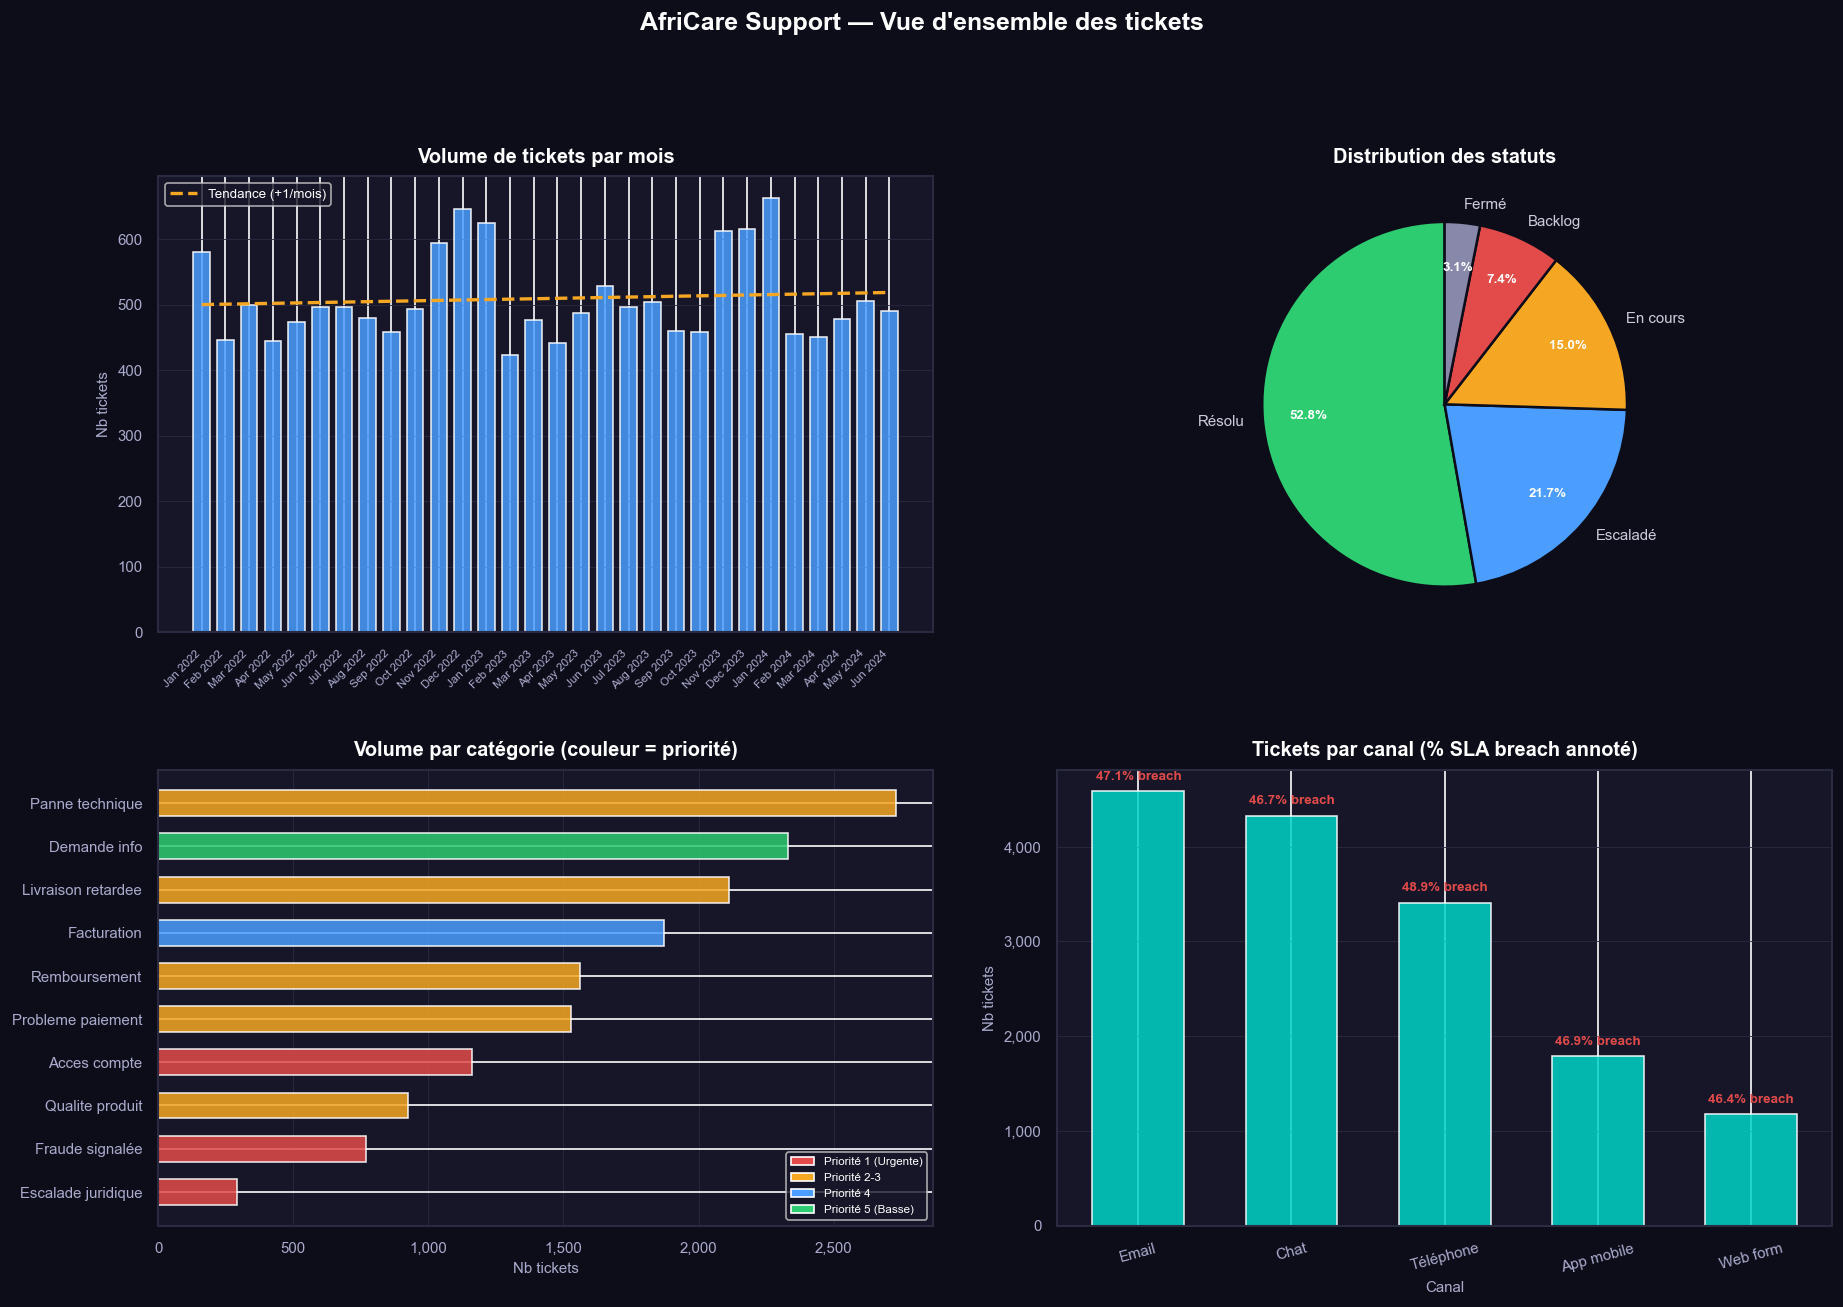

✅ Graphique sauvegardé : vue_ensemble_tickets.png


In [26]:
COLORS = {
    'blue':   '#4B9EFF', 'cyan':   '#00D4C8', 'violet': '#9B59FF',
    'orange': '#F5A623', 'red':    '#E24B4A', 'green':  '#2ECC71', 'gray': '#8888AA',
}
PRIO_COLORS = ['#E24B4A', '#F5A623', '#F5A623', '#4B9EFF', '#2ECC71']

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.patch.set_facecolor('#0D0D1A')
for ax in axes.flat:
    ax.set_facecolor('#161628')
    ax.tick_params(colors='#AAAACC', labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2A2A40')

fig.suptitle("AfriCare Support — Vue d'ensemble des tickets",
             fontsize=15, fontweight='bold', color='white', y=1.01)

# ── Graphique 1 : Volume par mois + tendance ──────────────────────────────────
ax1 = axes[0, 0]
x   = range(len(vol_mois))
ax1.bar(x, vol_mois['nb_tickets'], color=COLORS['blue'], alpha=0.85, width=0.7, zorder=2)

# Tendance linéaire
z = np.polyfit(list(x), vol_mois['nb_tickets'], 1)
p = np.poly1d(z)
ax1.plot(list(x), p(list(x)), color=COLORS['orange'], linewidth=2,
          linestyle='--', label=f'Tendance ({z[0]:+.0f}/mois)', zorder=3)

ax1.set_xticks(list(x))
ax1.set_xticklabels(vol_mois['mois_str'], rotation=45, ha='right', fontsize=7)
ax1.set_title('Volume de tickets par mois', color='white', fontweight='bold', pad=8)
ax1.set_ylabel('Nb tickets', color='#AAAACC', fontsize=9)
ax1.legend(facecolor='#161628', labelcolor='white', fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax1.grid(axis='y', color='#2A2A40', linewidth=0.5, zorder=1)

# ── Graphique 2 : Distribution statuts (donut) ───────────────────────────────
ax2 = axes[0, 1]
colors_statut = [COLORS['green'], COLORS['blue'], COLORS['orange'], COLORS['red'], COLORS['gray']]
wedges, texts, autotexts = ax2.pie(
    statuts_counts.values, labels=statuts_counts.index,
    autopct='%1.1f%%', colors=colors_statut[:len(statuts_counts)],
    startangle=90, pctdistance=0.75,
    wedgeprops={'edgecolor': '#0D0D1A', 'linewidth': 1.5}
)
for t in texts:      t.set_color('#CCCCDD'); t.set_fontsize(9)
for a in autotexts:  a.set_color('white');  a.set_fontsize(8); a.set_fontweight('bold')
ax2.set_title('Distribution des statuts', color='white', fontweight='bold', pad=8)

# ── Graphique 3 : Volume par catégorie ───────────────────────────────────────
ax3 = axes[1, 0]
prio_col = [PRIO_COLORS[int(p)-1] for p in vol_cat['priorite_defaut']]
ax3.barh(vol_cat['nom'], vol_cat['nb'], color=prio_col, alpha=0.85, height=0.6)
ax3.set_title('Volume par catégorie (couleur = priorité)', color='white', fontweight='bold', pad=8)
ax3.set_xlabel('Nb tickets', color='#AAAACC', fontsize=9)
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax3.grid(axis='x', color='#2A2A40', linewidth=0.5)

from matplotlib.patches import Patch
legend_e = [Patch(facecolor='#E24B4A', label='Priorité 1 (Urgente)'),
             Patch(facecolor='#F5A623', label='Priorité 2-3'),
             Patch(facecolor='#4B9EFF', label='Priorité 4'),
             Patch(facecolor='#2ECC71', label='Priorité 5 (Basse)')]
ax3.legend(handles=legend_e, facecolor='#161628', labelcolor='white', fontsize=7, loc='lower right')

# ── Graphique 4 : Canal + SLA breach annoté ──────────────────────────────────
ax4 = axes[1, 1]
bars4 = ax4.bar(vol_canal['canal'], vol_canal['nb_tickets'],
                 color=COLORS['cyan'], alpha=0.85, width=0.6, zorder=2)

for bar, (_, row) in zip(bars4, vol_canal.iterrows()):
    ax4.annotate(
        f"{row['taux_breach']}% breach",
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 5), textcoords='offset points',
        ha='center', va='bottom',
        color=COLORS['red'] if row['taux_breach'] > 25 else COLORS['orange'],
        fontsize=8, fontweight='bold'
    )

ax4.set_title('Tickets par canal (% SLA breach annoté)', color='white', fontweight='bold', pad=8)
ax4.set_ylabel('Nb tickets', color='#AAAACC', fontsize=9)
ax4.set_xlabel('Canal', color='#AAAACC', fontsize=9)
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax4.grid(axis='y', color='#2A2A40', linewidth=0.5, zorder=1)
ax4.tick_params(axis='x', rotation=15)

plt.tight_layout(pad=2.5)
plt.savefig('vue_ensemble_tickets.png', dpi=150, bbox_inches='tight', facecolor='#0D0D1A')
plt.show()
print("✅ Graphique sauvegardé : vue_ensemble_tickets.png")

### Lecture du graphique — Ce qu'on dit à M. Kouame

> 🎓 **Un graphique sans lecture n'est pas un livrable.**
> L'analyste doit systématiquement rédiger les insights qui en découlent.
> Ce paragraphe de lecture est ce qu'on inclut dans une présentation ou un email.
>
> Format attendu : chiffre précis → signification métier → implication ou action.

In [27]:
# Insights automatiques extraits des données
print("=" * 60)
print("  LECTURE DES GRAPHIQUES — INSIGHTS POUR M. KOUAME")
print("=" * 60)

# Insight 1 : tendance volumétrique
pente = np.polyfit(range(len(vol_mois)), vol_mois['nb_tickets'], 1)[0]
direction = "hausse" if pente > 0 else "baisse"
print(f"\n📈 Tendance : le volume de tickets est en {direction} de {abs(pente):.0f} tickets/mois")
print(f"   → Si la tendance se poursuit, les ressources actuelles devront être adaptées")

# Insight 2 : statuts problématiques
pct_problematiques = statuts_counts.get('Escaladé', 0) + statuts_counts.get('Backlog', 0)
pct_total = statuts_counts.sum()
print(f"\n⚠️  Statuts critiques : {pct_problematiques:,} tickets ({pct_problematiques/pct_total*100:.1f}%)")
print(f"   sont en backlog ou escaladés — c'est la base du problème identifié par M. Kouame")

# Insight 3 : canal avec le plus fort taux de breach
canal_critique = vol_canal.loc[vol_canal['taux_breach'].idxmax()]
print(f"\n🔴 Canal le plus à risque : {canal_critique['canal']}")
print(f"   Taux de SLA breach : {canal_critique['taux_breach']}%")
print(f"   → Action prioritaire : revoir la gestion des tickets sur ce canal")

# Insight 4 : taux global de breach
taux_breach_global = (tickets['sla_breach'].sum() / len(tickets) * 100)
print(f"\n📊 Taux global SLA breach : {taux_breach_global:.1f}%")
print(f"   Objectif standard du secteur : < 10%")
print(f"   Écart : {taux_breach_global - 10:.1f} points — {'critique' if taux_breach_global > 30 else 'élevé'}")

  LECTURE DES GRAPHIQUES — INSIGHTS POUR M. KOUAME

📈 Tendance : le volume de tickets est en hausse de 1 tickets/mois
   → Si la tendance se poursuit, les ressources actuelles devront être adaptées

⚠️  Statuts critiques : 4,449 tickets (29.1%)
   sont en backlog ou escaladés — c'est la base du problème identifié par M. Kouame

🔴 Canal le plus à risque : Téléphone
   Taux de SLA breach : 48.9%
   → Action prioritaire : revoir la gestion des tickets sur ce canal

📊 Taux global SLA breach : 47.3%
   Objectif standard du secteur : < 10%
   Écart : 37.3 points — critique


---

## ✅ Notebook 1 terminé

### Récapitulatif de ce qui a été réalisé

| Étape | Livrable | Statut |
|---|---|---|
| Brief métier | Traduction en 3 attentes analytiques précises | ✅ |
| Dictionnaire données | 5 tables documentées, colonnes critiques identifiées | ✅ |
| Réflexion stratégique | Variable cible ML définie, hypothèses CSAT documentées | ✅ |
| Chargement données | 5 CSV chargés avec parse_dates | ✅ |
| Audit types | Corrections de types identifiées et appliquées | ✅ |
| Audit nulls | Nulls légitimes vs problématiques distingués | ✅ |
| Audit doublons | Intégrité des clés primaires vérifiée | ✅ |
| Audit cohérence | Incohérences sla_breach/ratio_sla détectées et quantifiées | ✅ |
| Visualisation | Graphique 2×2 décisionnel avec insights rédigés | ✅ |

### Actions documentées pour le Notebook 2

1. Convertir `sla_strict` en booléen
2. Traiter les valeurs manquantes de `csat`
3. Supprimer ou corriger les délais négatifs
4. Corriger les incohérences `sla_breach` vs `ratio_sla`
5. Vérifier les clés FK orphelines
6. Créer la variable cible `ticket_at_risk`
7. Encoder les variables catégorielles pour le ML

---

**➡️ Prochaine étape → Notebook 2 : Nettoyage, Feature Engineering & EDA approfondie**

---

*DataProjectLab — apprendre la data sur des cas concrets, structurés et orientés métier.*